In [1]:
import os
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scanpy as sc
import torch
from matplotlib.colors import to_hex
from scipy.optimize import linear_sum_assignment

sys.path.append('../..')
import sherlock as slk

/opt/conda/envs/perturb/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
DEVICE      = torch.device("cuda" if torch.cuda.is_available() else "cpu")
N_RUNS      = 5
NUM_EPOCHS  = 200
VALIDATE_EVERY = 50
BATCH_SIZE  = 4096
LATENT_DIM  = 16
PATIENCE    = 20
RESULTS_DIR = "results/benchmarking"
N_CLUSTERS  = 10

# Metrics tracked for scoring and box plots
METRIC_COLS = [
    'cf_ate_pearson_r',
    'rho_z_pearson_r',
    'cluster_accuracy',
    'cluster_precision',
    'cluster_recall',
    'cluster_f1',
    'cluster_ari',
    'cluster_ami',
    'cluster_homogeneity',
    'cluster_completeness',
    'cluster_v_measure',
    'cluster_silhouette',
]

# (model_key, display_name, method-specific kwargs)
METHODS = [
    ("vae",  "sherlock", {"tau_end": 0.3, "cov_lambda": 0, "H_lambda": 0, "gate_row_repulsion_lambda": 0, "ce_lambda": 10.0}),
    ("svae", "sVAE",     {"sparse_mask_penalty": 10.0}),
    ("cvae", "cVAE",     {}),
]

os.makedirs(f"{RESULTS_DIR}/models",   exist_ok=True)
os.makedirs(f"{RESULTS_DIR}/figures",  exist_ok=True)

print(f"Device: {DEVICE}  Results: {RESULTS_DIR}")

Device: cuda  Results: results/benchmarking


## Data loading and ground-truth ATE

In [4]:
data = slk.datasets.replogle()

slk.pp.treat_effect(
    data,
    label_col='pert',
    control_label='NTC',
    method='perturbseq',
    inplace=True,
    key='treat_effect',
)
treat_effect_adata = data.uns['treat_effect']
print(f"Cells: {data.n_obs}  Genes: {data.n_vars}  Perturbations: {data.obs['pert'].nunique()}")

100%|██████████| 681/681 [00:08<00:00, 78.91it/s]

Cells: 118641  Genes: 1185  Perturbations: 682


## Pathway annotations for clustering evaluation

In [5]:
pathways = data.uns['pathways']

all_genes_filtered = [
    gene
    for genes in pathways.values()
    for gene in genes
    if gene != 'LSM5'
]

gene_to_pathway = {
    gene: pathway
    for pathway, genes in pathways.items()
    for gene in genes
    if gene != 'LSM5'
}
pathway_df_indexed = pd.DataFrame.from_dict(
    gene_to_pathway, orient='index', columns=['pathway']
)
pathway_df_indexed.index.name = 'gene'

print(f"Pathway genes: {len(all_genes_filtered)}  Pathways: {len(pathways)}")

Pathway genes: 335  Pathways: 8


## Benchmark loop

Each method is trained `N_RUNS` times independently. The best-scoring run
per method is saved to `results/models/`. Metrics are computed after training
using the proper counterfactual ATE protocol; the clustering cut is chosen
automatically via the elbow method.

In [6]:
records         = []
best_run_out    = {}   # method → out dict of best single run
best_run_model  = {}   # method → model of best single run
best_run_score  = {}   # method → avg metric score of best single run

for model_key, display_name, extra_kwargs in METHODS:
    print(f"\n{'='*60}\n{display_name}  ({N_RUNS} runs)\n{'='*60}")
    best_run_score[display_name] = -np.inf

    for run in range(N_RUNS):
        print(f"\n  -- {display_name} run {run + 1}/{N_RUNS} --")

        out = slk.tl.run(
            data,
            model=model_key,
            batch_size=BATCH_SIZE,
            num_epochs=NUM_EPOCHS,
            device=DEVICE,
            latent_dim=LATENT_DIM,
            patience=PATIENCE,
            validate_every=VALIDATE_EVERY,
            **extra_kwargs,
        )
        model = out['model']

        metrics = slk.tl.evaluate_model(
            model,
            data,
            treat_effect_adata,
            pathway_df_indexed,
            all_genes_filtered,
            n_clusters=N_CLUSTERS,
            device=DEVICE,
        )

        # Track best run for this method
        run_avg = float(np.nanmean([metrics[k] for k in METRIC_COLS]))
        if run_avg > best_run_score[display_name]:
            best_run_score[display_name] = run_avg
            best_run_out[display_name]   = out
            best_run_model[display_name] = model

        metrics['method'] = display_name
        metrics['run']    = run
        records.append(metrics)

        for k, v in metrics.items():
            if k not in ('method', 'run'):
                val_str = f"{v:.4f}" if np.isfinite(float(v)) else "NaN"
                print(f"    {k:30s} = {val_str}")

    # Save best run model for this method
    save_path = f"{RESULTS_DIR}/models/{display_name}_best.pth"
    slk.tl.save_results(best_run_out[display_name], save_path)
    print(f"\n  Saved best {display_name} model → {save_path}")

results_df = pd.DataFrame(records)
print("\nDone.")


sherlock  (5 runs)

  -- sherlock run 1/5 --
Training VAE on cuda …


Epochs: 100%|██████████| 200/200 [13:52<00:00,  4.16s/it, ATE=0.7647, CE=3.0553, ELBO=128258.7721, R2_ntc=0.9649, R2_p=0.9382, acc=0.346, pi25=0.18, pi99=0.95, tau=0.300]


    cf_ate_pearson_r               = 0.3287
    cluster_accuracy               = 0.8448
    cluster_precision              = 0.7985
    cluster_recall                 = 0.7852
    cluster_f1                     = 0.7832
    cluster_ari                    = 0.6246
    cluster_ami                    = 0.7404
    cluster_homogeneity            = 0.8055
    cluster_completeness           = 0.7077
    cluster_v_measure              = 0.7534
    cluster_silhouette             = 0.2662
    cluster_purity                 = 0.8567
    cluster_knn_purity             = 0.9158
    cluster_linear_probe           = 0.9522
    rho_z_pearson_r                = 0.7319

  -- sherlock run 2/5 --
Training VAE on cuda …


Epochs: 100%|██████████| 200/200 [13:47<00:00,  4.14s/it, ATE=0.7667, CE=3.2137, ELBO=133481.4684, R2_ntc=0.9649, R2_p=0.9390, acc=0.319, pi25=0.17, pi99=0.95, tau=0.300]


    cf_ate_pearson_r               = 0.3422
    cluster_accuracy               = 0.8448
    cluster_precision              = 0.8402
    cluster_recall                 = 0.8032
    cluster_f1                     = 0.8170
    cluster_ari                    = 0.7246
    cluster_ami                    = 0.7477
    cluster_homogeneity            = 0.7935
    cluster_completeness           = 0.7307
    cluster_v_measure              = 0.7608
    cluster_silhouette             = 0.2640
    cluster_purity                 = 0.8448
    cluster_knn_purity             = 0.9385
    cluster_linear_probe           = 0.9821
    rho_z_pearson_r                = 0.7402

  -- sherlock run 3/5 --
Training VAE on cuda …


...

    cf_ate_pearson_r               = 0.3837
    cluster_accuracy               = 0.2806
    cluster_precision              = 0.2535
    cluster_recall                 = 0.2610
    cluster_f1                     = 0.2523
    cluster_ari                    = 0.0212
    cluster_ami                    = 0.0561
    cluster_homogeneity            = 0.1109
    cluster_completeness           = 0.0953
    cluster_v_measure              = 0.1025
    cluster_silhouette             = -0.0003
    cluster_purity                 = 0.3313
    cluster_knn_purity             = 0.4794
    cluster_linear_probe           = 0.9940
    rho_z_pearson_r                = 0.9023

  -- cVAE run 4/5 --


cVAE: 100%|██████████| 200/200 [08:01<00:00,  2.41s/it, ATE=0.8117, KLw=1.00, R2=0.9649, loss=211553647.4483]


    cf_ate_pearson_r               = 0.3837
    cluster_accuracy               = 0.2806
    cluster_precision              = 0.2535
    cluster_recall                 = 0.2610
    cluster_f1                     = 0.2523
    cluster_ari                    = 0.0212
    cluster_ami                    = 0.0561
    cluster_homogeneity            = 0.1109
    cluster_completeness           = 0.0953
    cluster_v_measure              = 0.1025
    cluster_silhouette             = -0.0003
    cluster_purity                 = 0.3313
    cluster_knn_purity             = 0.4794
    cluster_linear_probe           = 0.9940
    rho_z_pearson_r                = 0.9023

  -- cVAE run 5/5 --


cVAE: 100%|██████████| 200/200 [08:04<00:00,  2.42s/it, ATE=0.8117, KLw=1.00, R2=0.9649, loss=211553647.4483]


    cf_ate_pearson_r               = 0.3837
    cluster_accuracy               = 0.2806
    cluster_precision              = 0.2535
    cluster_recall                 = 0.2610
    cluster_f1                     = 0.2523
    cluster_ari                    = 0.0212
    cluster_ami                    = 0.0561
    cluster_homogeneity            = 0.1109
    cluster_completeness           = 0.0953
    cluster_v_measure              = 0.1025
    cluster_silhouette             = -0.0003
    cluster_purity                 = 0.3313
    cluster_knn_purity             = 0.4794
    cluster_linear_probe           = 0.9940
    rho_z_pearson_r                = 0.9023

  Saved best cVAE model → results/benchmarking/models/cVAE_best.pth

Done.


## Results summary

In [7]:
summary = (
    results_df
    .groupby('method')[METRIC_COLS]
    .agg(['mean', 'std'])
    .round(4)
)
print(summary.to_string())

         cf_ate_pearson_r         rho_z_pearson_r         cluster_accuracy         cluster_precision         cluster_recall         cluster_f1         cluster_ari         cluster_ami         cluster_homogeneity         cluster_completeness         cluster_v_measure         cluster_silhouette        
                     mean     std            mean     std             mean     std              mean     std           mean     std       mean     std        mean     std        mean     std                mean     std                 mean     std              mean     std               mean     std
method                                                                                                                                                                                                                                                                                                      
cVAE               0.3851  0.0031          0.8942  0.0181           0.2878  0.0160            0.2

## Box plots

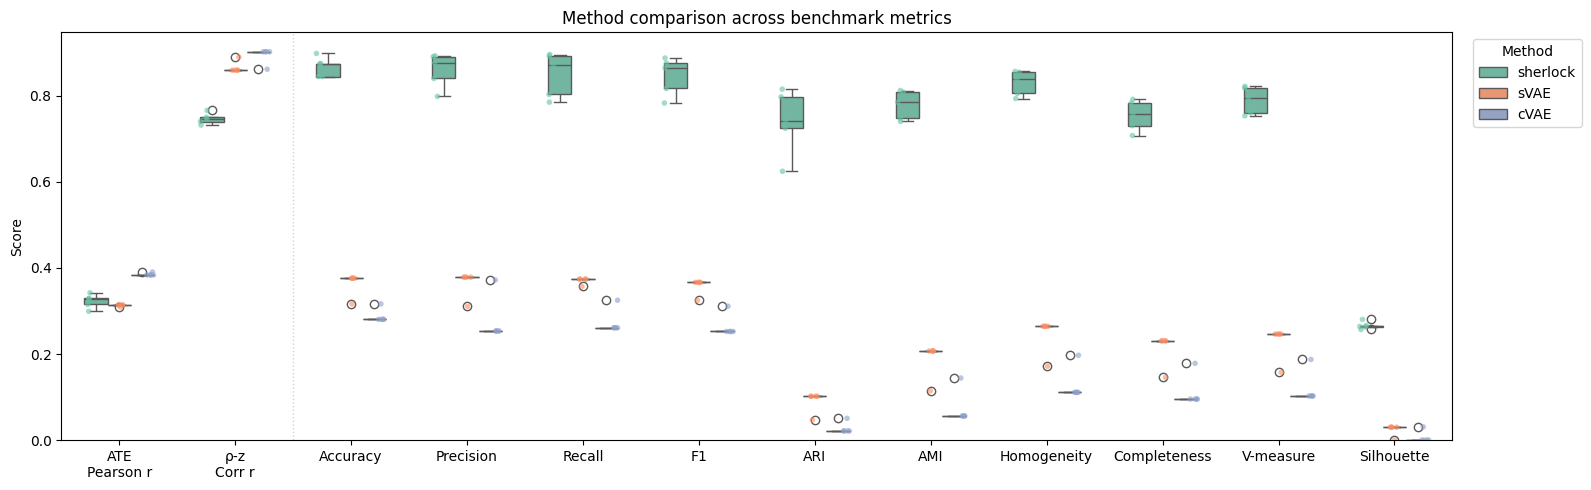

In [8]:
label_map = {
    'cf_ate_pearson_r':    'ATE\nPearson r',
    'rho_z_pearson_r':     'ρ-z\nCorr r',
    'cluster_accuracy':    'Accuracy',
    'cluster_precision':   'Precision',
    'cluster_recall':      'Recall',
    'cluster_f1':          'F1',
    'cluster_ari':         'ARI',
    'cluster_ami':         'AMI',
    'cluster_homogeneity': 'Homogeneity',
    'cluster_completeness':'Completeness',
    'cluster_v_measure':   'V-measure',
    'cluster_silhouette':  'Silhouette',
}

df_melted = results_df.melt(
    id_vars='method', value_vars=METRIC_COLS, var_name='metric', value_name='value'
)

df_melted['metric_label'] = pd.Categorical(
    df_melted['metric'].map(label_map),
    categories=[label_map[m] for m in METRIC_COLS],
    ordered=True,
)

# Clamp values at 0 for display
df_melted['value'] = df_melted['value'].clip(lower=0)

# Check whether every method-metric pair has only one sample
counts = df_melted.groupby(['metric', 'method'])['value'].size()
single_sample_per_metric = counts.max() == 1

fig, ax = plt.subplots(figsize=(16, 5))

if single_sample_per_metric:
    sns.barplot(
        data=df_melted,
        x='metric_label',
        y='value',
        hue='method',
        palette='Set2',
        ax=ax,
        errorbar=None,
    )
else:
    sns.boxplot(
        data=df_melted,
        x='metric_label',
        y='value',
        hue='method',
        palette='Set2',
        width=0.6,
        ax=ax,
    )
    sns.stripplot(
        data=df_melted,
        x='metric_label',
        y='value',
        hue='method',
        palette='Set2',
        dodge=True,
        size=4,
        alpha=0.6,
        legend=False,
        ax=ax,
    )

ax.set_xlabel('')
ax.set_ylabel('Score')
ax.set_title('Method comparison across benchmark metrics')
ax.legend(title='Method', bbox_to_anchor=(1.01, 1), loc='upper left')
ax.set_ylim(bottom=0)
ax.axhline(0, color='gray', linewidth=0.5, linestyle='--')

# Separator between ATE/rho metrics and clustering metrics
ax.axvline(1.5, color='lightgray', linewidth=1.0, linestyle=':')

plt.tight_layout()

plot_name = 'benchmark_barplot.pdf' if single_sample_per_metric else 'benchmark_boxplot.pdf'
plt.savefig(f'{RESULTS_DIR}/figures/{plot_name}', bbox_inches='tight')
plt.show()

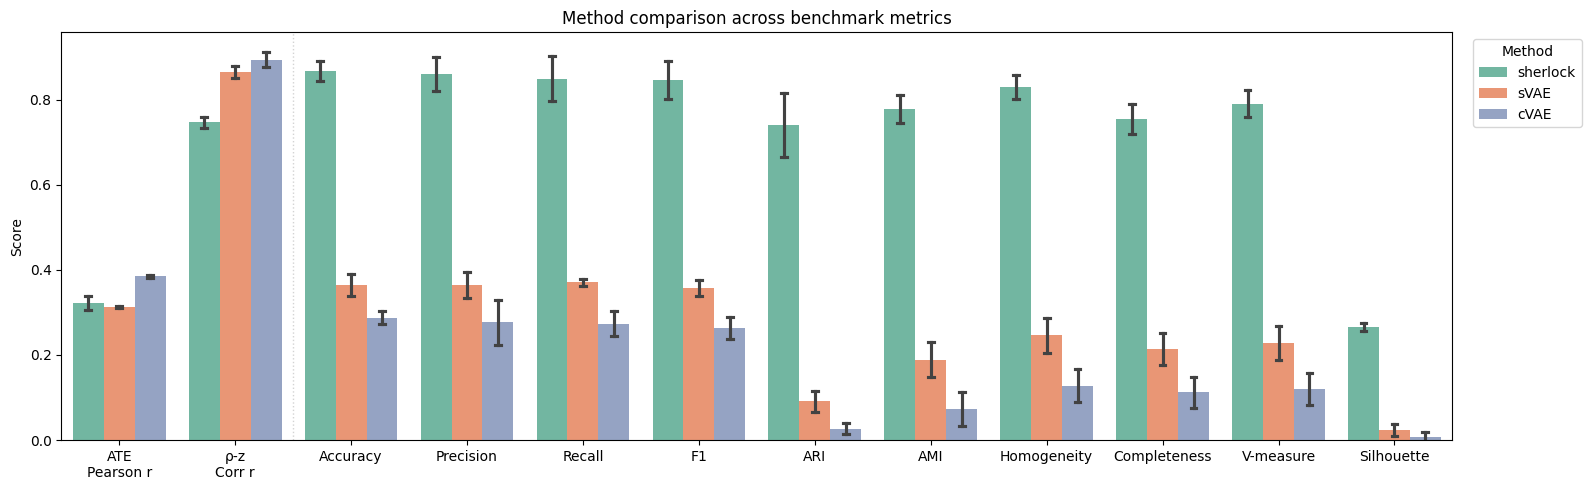

In [11]:
label_map = {
    'cf_ate_pearson_r':    'ATE\nPearson r',
    'rho_z_pearson_r':     'ρ-z\nCorr r',
    'cluster_accuracy':    'Accuracy',
    'cluster_precision':   'Precision',
    'cluster_recall':      'Recall',
    'cluster_f1':          'F1',
    'cluster_ari':         'ARI',
    'cluster_ami':         'AMI',
    'cluster_homogeneity': 'Homogeneity',
    'cluster_completeness':'Completeness',
    'cluster_v_measure':   'V-measure',
    'cluster_silhouette':  'Silhouette',
}

df_melted = results_df.melt(
    id_vars='method',
    value_vars=METRIC_COLS,
    var_name='metric',
    value_name='value',
)

df_melted['metric_label'] = pd.Categorical(
    df_melted['metric'].map(label_map),
    categories=[label_map[m] for m in METRIC_COLS],
    ordered=True,
)

# Clamp values at 0 for display
df_melted['value'] = df_melted['value'].clip(lower=0)

fig, ax = plt.subplots(figsize=(16, 5))

sns.barplot(
    data=df_melted,
    x='metric_label',
    y='value',
    hue='method',
    palette='Set2',
    errorbar='sd',   # standard deviation bars
    capsize=0.15,
    ax=ax,
)

ax.set_xlabel('')
ax.set_ylabel('Score')
ax.set_title('Method comparison across benchmark metrics')
ax.legend(title='Method', bbox_to_anchor=(1.01, 1), loc='upper left')
ax.set_ylim(bottom=0)
ax.axhline(0, color='gray', linewidth=0.5, linestyle='--')

# Separator between ATE/rho metrics and clustering metrics
ax.axvline(1.5, color='lightgray', linewidth=1.0, linestyle=':')

plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/figures/benchmark_barplot.pdf', bbox_inches='tight')
plt.show()

## Per-method best models — latent space UMAPs

For each method, re-eval the best run, compute UMAP on non-NTC cells, cluster the
pathway-gene subset of rho_corr (elbow cut), align predicted clusters to true pathways
via Hungarian matching, and save the figure.


Generating figure for best sherlock model


/var/tmp/ipykernel_2749935/1051879524.py:69: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_col       = plt.cm.get_cmap('tab20', len(all_cats))


  Saved → results/benchmarking/figures/sherlock_best_umap.pdf


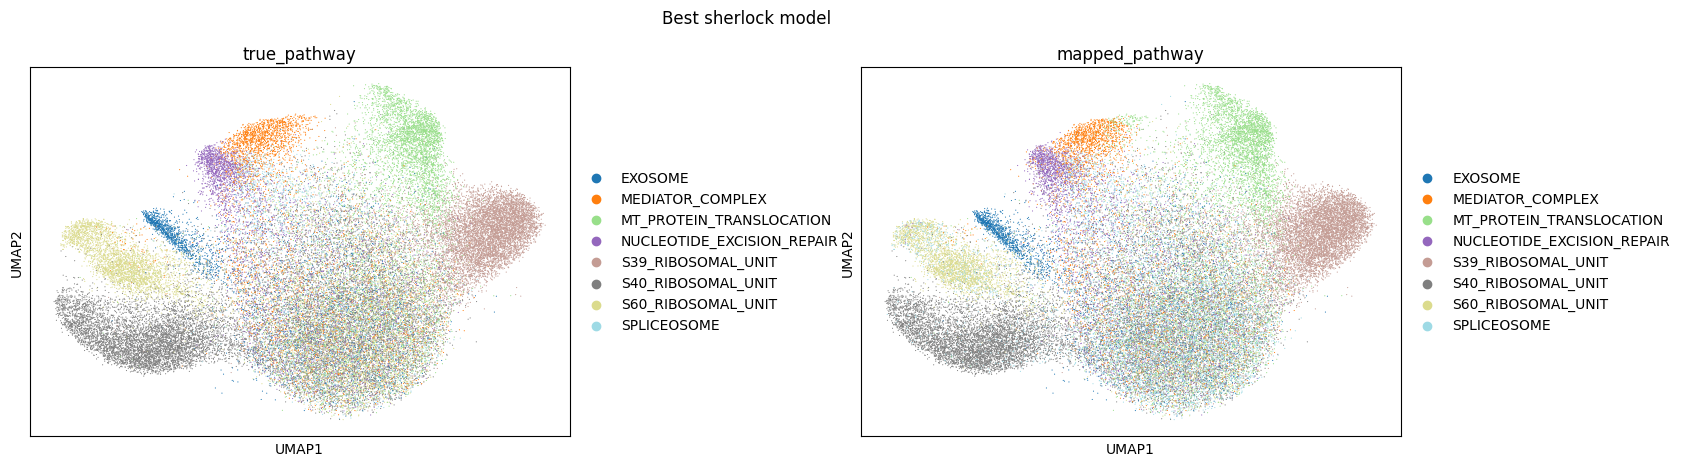


Generating figure for best sVAE model


/var/tmp/ipykernel_2749935/1051879524.py:69: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_col       = plt.cm.get_cmap('tab20', len(all_cats))


  Saved → results/benchmarking/figures/sVAE_best_umap.pdf


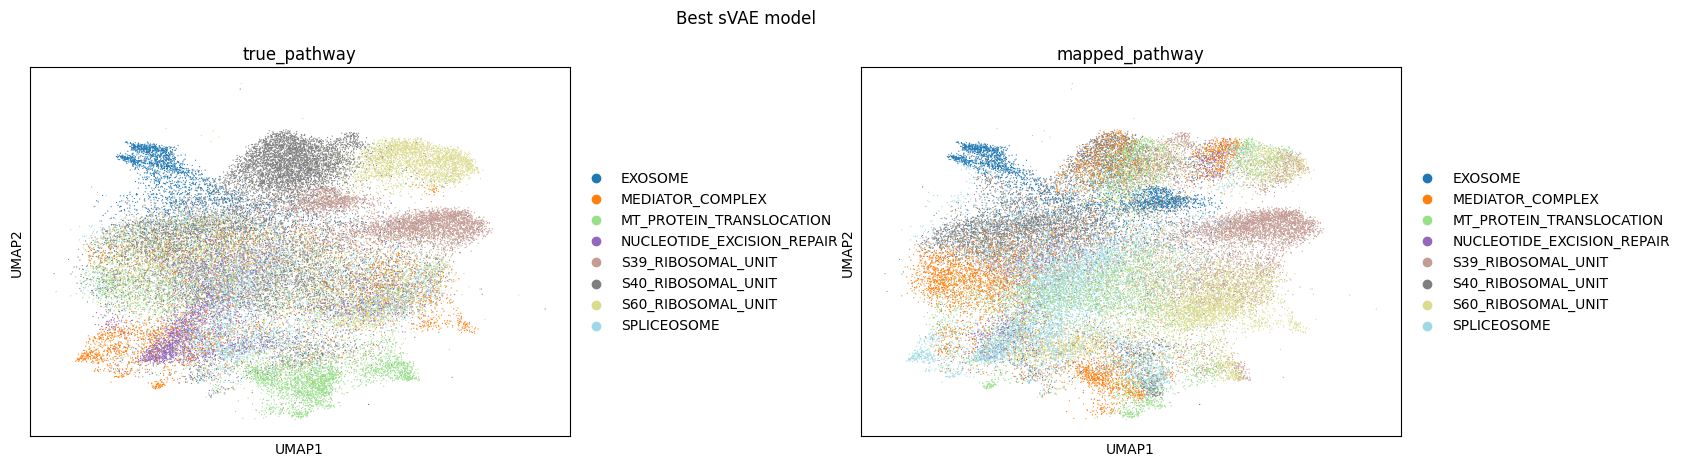


Generating figure for best cVAE model


/var/tmp/ipykernel_2749935/1051879524.py:69: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_col       = plt.cm.get_cmap('tab20', len(all_cats))


  Saved → results/benchmarking/figures/cVAE_best_umap.pdf


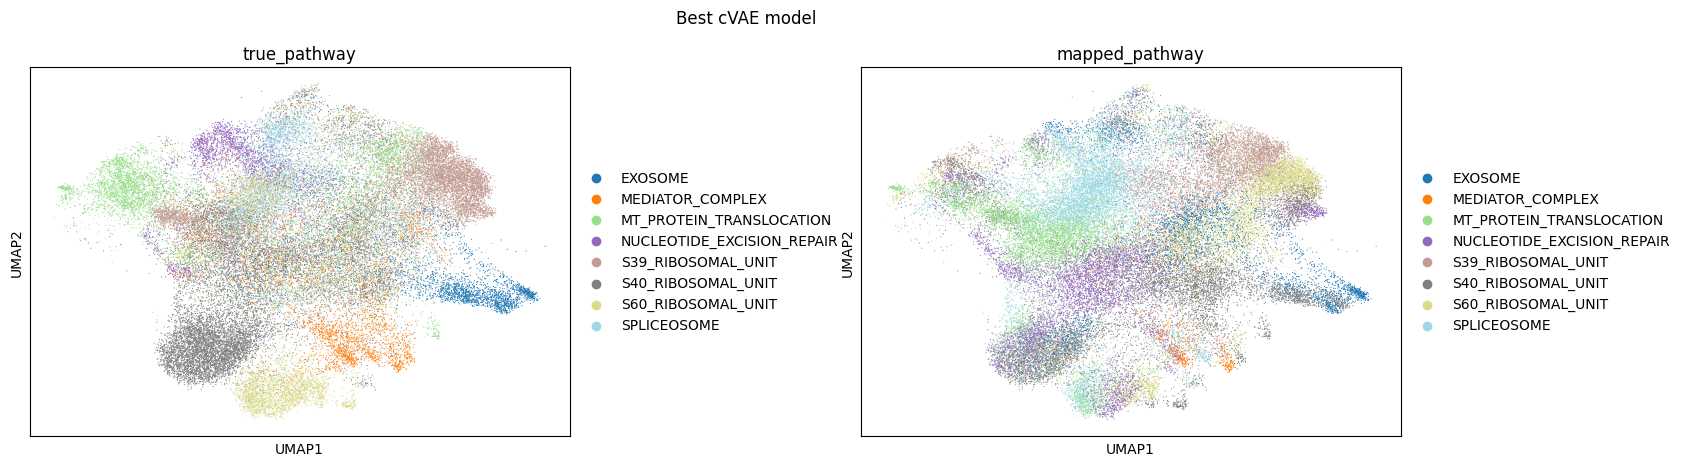

In [9]:
p_key = slk.configs.get_config('pert_key')
NTC   = slk.configs.get_config('ntc_label')

for method_name, model in best_run_model.items():
    print(f"\n{'='*60}\nGenerating figure for best {method_name} model\n{'='*60}")

    # Re-eval the best model for this method
    slk.tl.eval(model, data, obsm_key='z', uns_key='results', device=DEVICE)

    # UMAP on non-NTC cells
    sub = data[data.obs[p_key] != NTC].copy()
    sc.pp.neighbors(sub, n_neighbors=15, use_rep='z')
    sc.tl.umap(sub)

    # Cluster rho_corr on pathway genes
    rho_corr  = np.asarray(data.uns['results']['rho_corr'])
    rho_perts = np.asarray(data.uns['results']['rho_perts'])

    pert_to_idx = {name: i for i, name in enumerate(rho_perts)}
    valid_genes = [g for g in all_genes_filtered if g in pert_to_idx]
    gene_ids    = [pert_to_idx[g] for g in valid_genes]

    cov_subset = rho_corr[np.ix_(gene_ids, gene_ids)]
    cov_subset = np.clip(cov_subset, -1.0, 1.0)
    cov_subset = 0.5 * (cov_subset + cov_subset.T)
    np.fill_diagonal(cov_subset, 1.0)

    groups = slk.tl.cluster_rho(data, t=N_CLUSTERS, rho_corr=cov_subset, criterion='maxclust', show=False)

    # Hungarian alignment of cluster → pathway labels
    clusters_df = pd.DataFrame({'gene': valid_genes, 'cluster': groups})
    pw_df = pathway_df_indexed.loc[pathway_df_indexed.index.isin(valid_genes)].reset_index()
    if 'gene' not in pw_df.columns:
        pw_df = pw_df.rename(columns={pathway_df_indexed.index.name or 'index': 'gene'})

    df_align  = pd.merge(clusters_df, pw_df, on='gene', how='inner')
    y_true    = df_align['pathway'].astype(str).values
    y_pred    = df_align['cluster'].astype(str).values
    true_lbl  = np.unique(y_true)
    pred_lbl  = np.unique(y_pred)

    C_mat = (
        pd.crosstab(df_align['pathway'].astype(str), df_align['cluster'].astype(str))
        .reindex(index=true_lbl, columns=pred_lbl, fill_value=0)
    )
    row_ind, col_ind = linear_sum_assignment(C_mat.values.max() - C_mat.values)
    mapping = {pred_lbl[j]: true_lbl[i] for i, j in zip(row_ind, col_ind)}
    df_align['mapped_pathway'] = [mapping.get(str(cl)) for cl in y_pred]

    # Subset z_sub to clustered genes and attach pathway labels
    clustered_genes = df_align['gene'].unique()
    z_sub = sub[sub.obs[p_key].isin(clustered_genes)].copy()

    gene_to_true   = dict(zip(df_align['gene'], df_align['pathway']))
    gene_to_mapped = dict(zip(df_align['gene'], df_align['mapped_pathway']))
    z_sub.obs['true_pathway']   = z_sub.obs[p_key].map(gene_to_true)
    z_sub.obs['mapped_pathway'] = z_sub.obs[p_key].map(gene_to_mapped)
    z_sub = z_sub[z_sub.obs['mapped_pathway'].notna()].copy()

    # Shared categorical palette across both columns
    all_cats  = pd.Index(np.unique(
        list(z_sub.obs['true_pathway'].dropna().unique()) +
        list(z_sub.obs['mapped_pathway'].dropna().unique())
    ).astype(str))
    cat_dtype = pd.api.types.CategoricalDtype(categories=all_cats, ordered=False)
    z_sub.obs['true_pathway']   = z_sub.obs['true_pathway'].astype('string').astype(cat_dtype)
    z_sub.obs['mapped_pathway'] = z_sub.obs['mapped_pathway'].astype('string').astype(cat_dtype)

    cmap_col       = plt.cm.get_cmap('tab20', len(all_cats))
    shared_palette = {cat: to_hex(cmap_col(i)) for i, cat in enumerate(all_cats)}
    z_sub.uns['true_pathway_colors']   = [shared_palette[c] for c in z_sub.obs['true_pathway'].cat.categories]
    z_sub.uns['mapped_pathway_colors'] = [shared_palette[c] for c in z_sub.obs['mapped_pathway'].cat.categories]

    # Plot and save
    fig = sc.pl.umap(
        z_sub,
        color=['true_pathway', 'mapped_pathway'],
        wspace=0.4,
        show=False,
        return_fig=True,
    )
    fig.suptitle(f'Best {method_name} model', y=1.02, fontsize=12)
    save_path = f'{RESULTS_DIR}/figures/{method_name}_best_umap.pdf'
    fig.savefig(save_path, bbox_inches='tight')
    print(f"  Saved → {save_path}")
    plt.show()